In [1]:
import os, math, json, random, time
from collections import defaultdict
import dotenv
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
import umap
import hdbscan
from textwrap import fill

from openai import OpenAI
from googleapiclient.discovery import build

In [2]:
dotenv.load_dotenv()

True

In [3]:
# OpenAI Token eingeben
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [4]:
# YouTube - Konfiguration

VIDEO_ID = "6dWYxKW5rY4"
YOUTUBE_API_KEY = os.getenv("YOUTUBE_DATA_API_KEY")
MAX_PAGES = 5 
ORDER = "relevance"


# Konfiguration für OpenAI API

OpenAI bietet auch ein Moderation-Modell an, um die schädlichen Inhalte zu identifizieren. - siehe [Hier](https://platform.openai.com/docs/models/omni-moderation-latest)

In [5]:
# OpenAI API - Konfiguration

## Modelle
PREPROCESS_MODEL = "gpt-4o-mini"
EMBED_MODEL = "text-embedding-3-small"
LABEL_MODEL = "gpt-4o-mini"
USE_MODERATION = False

## Für Reproduzierbarkeit der Ergebnisse - [hier](https://platform.openai.com/docs/advanced-usage)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [6]:
# Parameters für UMAP

UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"


In [7]:
def fetch_comments(video_id: str, api_key: str, max_pages: int = 5, order: str = "relevance"):
    yt = build("youtube", "v3", developerKey=api_key)
    comments = []
    page_token = None
    pages = 0
    while pages < max_pages:
        resp = yt.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            pageToken=page_token,
            textFormat="plainText",
            order=order
        ).execute()
        for item in resp.get("items", []):
            top = item["snippet"]["topLevelComment"]["snippet"]
            text = (top.get("textDisplay") or top.get("textOriginal") or "").strip()
            if not text:
                continue
            comments.append({
                "comment_id": item["id"],
                "text": text,
                "likeCount": int(top.get("likeCount", 0)),
                "publishedAt": top.get("publishedAt", ""),
                "author": top.get("authorDisplayName", "")
            })
        page_token = resp.get("nextPageToken")
        pages += 1
        if not page_token:
            break
    return pd.DataFrame(comments)

raw_df = fetch_comments(VIDEO_ID, YOUTUBE_API_KEY, max_pages=MAX_PAGES, order=ORDER)
print(f"Fetched {len(raw_df)} comments")
raw_df.head()


Fetched 194 comments


,comment_id,text,likeCount,publishedAt,author
0,UgzVWa_cYdI_xkD8mCx4AaABAg,Wir schaffen uns ab.,243,2025-09-05T12:17:58Z,@xwalleex
1,Ugw8bPkjruq7dOuNMPh4AaABAg,Merz - Verschwinde!,149,2025-09-05T12:23:37Z,@Trunksliderman
2,UgxWSqIXuOb7XSIXLd94AaABAg,Super geil gemacht das Video 👍Nicht aufgeben A...,47,2025-09-05T12:46:10Z,@K.Franz1963
3,UgwNQ_gg9oo8Bp5lZgd4AaABAg,"Darf man sich eigentlich wünschen, dass Verant...",56,2025-09-05T12:26:14Z,@christopherreichelt3303
4,Ugw7e5GR0WWidimIFgB4AaABAg,"Wir brauchen 51%, dafür zählt jede einzelne St...",152,2025-09-05T12:27:02Z,@lb-ns4kj


In [8]:
# Hier die Funktion für omni-moderation
def moderate_texts(texts):
    
    flagged = []
    keep = []
    if not texts:
        return keep, flagged
    try:
        resp = client.moderations.create(
            model="omni-moderation-latest",
            input=texts
        )
        for t, r in zip(texts, resp.results):
            if r.flagged:
                flagged.append(t)
            else:
                keep.append(t)
    except Exception as e:
        print("Moderation error:", e)
        keep = texts
    return keep, flagged

if USE_MODERATION:
    keep_texts, flagged_texts = moderate_texts(raw_df["text"].tolist())
    df = raw_df[raw_df["text"].isin(keep_texts)].reset_index(drop=True)
    print(f"Kept {len(df)} / Flagged {len(flagged_texts)}")
else:
    df = raw_df.copy()
df.head()

,comment_id,text,likeCount,publishedAt,author
0,UgzVWa_cYdI_xkD8mCx4AaABAg,Wir schaffen uns ab.,243,2025-09-05T12:17:58Z,@xwalleex
1,Ugw8bPkjruq7dOuNMPh4AaABAg,Merz - Verschwinde!,149,2025-09-05T12:23:37Z,@Trunksliderman
2,UgxWSqIXuOb7XSIXLd94AaABAg,Super geil gemacht das Video 👍Nicht aufgeben A...,47,2025-09-05T12:46:10Z,@K.Franz1963
3,UgwNQ_gg9oo8Bp5lZgd4AaABAg,"Darf man sich eigentlich wünschen, dass Verant...",56,2025-09-05T12:26:14Z,@christopherreichelt3303
4,Ugw7e5GR0WWidimIFgB4AaABAg,"Wir brauchen 51%, dafür zählt jede einzelne St...",152,2025-09-05T12:27:02Z,@lb-ns4kj


# Embedding

In [9]:
texts = df["text"].fillna("").astype(str).tolist()
emb = client.embeddings.create(
    model=EMBED_MODEL,
    input=texts
)
X = np.array([d.embedding for d in emb.data], dtype="float32")
X.shape

(194, 1536)

# Clustering 

In [10]:
# L2-Normalisierung (für cosine-Methode)
Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

# Reduktion der Dimenstion mit PCA 
USE_PCA = True
if USE_PCA:
    pca = PCA(n_components=50, random_state=SEED)
    Xc = pca.fit_transform(Xn)
    HDBSCAN_METRIC = "cosine"
else:
    Xc = Xn
    HDBSCAN_METRIC = "euclidean"

# HDBSCAN mit cosine oder euclidean
N = len(Xc)
HDBSCAN_MIN_CLUSTER_SIZE = max(5, int(0.01 * N))   # データの~1%か5の大きい方
HDBSCAN_MIN_SAMPLES = max(1, int(0.005 * N))       # データの~0.5%か1

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric="euclidean" if USE_PCA else "cosine",
    cluster_selection_method="leaf",   # "eom" oder "leaf" 
    prediction_data=True
)
labels = clusterer.fit_predict(Xc)

df["cluster"] = labels
df["is_noise"] = (labels == -1)
print(
    "clusters:", sorted(set(labels) - {-1}),
    "| noise_ratio:", round(df["is_noise"].mean(), 3)
)

clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] | noise_ratio: 0.536


/Users/nobu/openaiapi/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/nobu/openaiapi/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/nobu/openaiapi/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/nobu/openaiapi/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/nobu/openaiapi/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/nobu/openaiapi/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users

In [12]:
def pick_representatives(rows: pd.DataFrame, topn: int = 15):
    rows = rows.copy()
    col = "text" 
    rows[col] = rows[col].fillna("").astype(str).str.strip()
    rows["len"] = rows[col].str.len()
    rows = rows[(rows["len"] >= 5) & (rows["len"] <= 300)]
    rows = rows.sort_values(["likeCount", "len"], ascending=[False, True])
    uniq, seen = [], set()
    for t in rows[col].tolist():
        if not t:
            continue
        key = t.lower()
        if key not in seen:
            uniq.append(t)
            seen.add(key)
        if len(uniq) >= topn:
            break
    return uniq

def label_cluster(samples, model=LABEL_MODEL, temperature=0.2, seed: int = SEED):
    schema = {
      "type": "object",
      "properties": {
        "label": {"type":"string"},
        "summary": {"type":"string"},
        "keywords": {"type":"array","items":{"type":"string"}}
      },
      "required": ["label","summary"]
    }
    prompt = (
        "Unten findest du repräsentative YouTube-Kommentare, die zum selben Thema gehören. "
        "Auf Basis der Gemeinsamkeiten sollst du **ausschließlich JSON** mit folgendem Schema zurückgeben:\n"
        "{\n"
        '  "label": kurze, konkrete Bezeichnung (auf Deutsch, max. 25 Zeichen),\n'
        '  "summary": Zusammenfassung in 2–3 Sätzen (auf Deutsch),\n'
        '  "keywords": 3–6 Stichwörter (auf Deutsch)\n'
        "}\n\n"
        "Kommentare:\n- " + "\n- ".join(samples)
    )
    resp = client.chat.completions.create(
        model=model,
        temperature=temperature,
        seed=seed,
        messages=[
            {"role": "system", "content": "Du bist ein Assistent für Forschungsdatenanalyse. Antworte strikt im JSON-Format und auf Deutsch."},
            {"role": "user", "content": prompt}
        ],
        response_format={"type": "json_object"}
    )
    parsed = json.loads(resp.choices[0].message.content)

    return parsed, resp.system_fingerprint

cluster_summaries = {}
fingerprints = {}

for cid in sorted([c for c in df["cluster"].unique() if c != -1]):
    reps = pick_representatives(df[df["cluster"] == cid], topn=15)
    try:
        out, fp = label_cluster(reps)
        cluster_summaries[int(cid)] = out
        fingerprints[int(cid)] = fp
    except Exception as e:
        cluster_summaries[int(cid)] = {"label": "(Fehlgeschlagen)", "summary": str(e), "keywords": []}
        fingerprints[int(cid)] = None

len(cluster_summaries), list(cluster_summaries.items())[:2]

(9,
 [(0,
   {'label': 'Verantwortung und Konsequenzen',
    'summary': 'Die Kommentare drücken den Wunsch aus, dass politische Verantwortliche für ihre Entscheidungen zur Rechenschaft gezogen werden. Es wird gefordert, dass diese Personen endlich Konsequenzen für ihr Handeln erfahren und angeklagt werden.',
    'keywords': ['Verantwortung',
     'Anklage',
     'Politik',
     'Konsequenzen',
     'Merkel']}),
  (1,
   {'label': 'Trauer um Deutschland',
    'summary': 'Die Kommentare drücken eine tiefe Traurigkeit und Enttäuschung über den aktuellen Zustand Deutschlands aus. Viele Nutzer fühlen sich von den Veränderungen im Land betroffen und wünschen sich eine Rückkehr zu besseren Zeiten.',
    'keywords': ['Traurigkeit',
     'Veränderung',
     'Nostalgie',
     'Enttäuschung',
     'Deutschland']})])

In [25]:

records = []
for cid in sorted(df["cluster"].unique()):
    info = cluster_summaries.get(int(cid), {})
    members = df[df["cluster"]==cid]
    records.append({
        "cluster_id": int(cid),
        "size": int(len(members)),
        "label": info.get("label","") if cid!=-1 else "(Noise)",
        "summary": info.get("summary","") if cid!=-1 else "",
        "keywords": ", ".join(info.get("keywords", [])) if cid!=-1 else ""
    })
report = pd.DataFrame(records).sort_values(["cluster_id","size"]).reset_index(drop=True)
display(report.head(20))

# 保存
os.makedirs("outputs", exist_ok=True)
report_path = "outputs/cluster_report_B.csv"
comments_path = "outputs/comments_B.csv"
config_path = "outputs/config_B.json"

report.to_csv(report_path, index=False)
df.to_csv(comments_path, index=False)

config = {
    "video_id": VIDEO_ID,
    "order": ORDER,
    "max_pages": MAX_PAGES,
    "preprocess_model": PREPROCESS_MODEL,
    "embed_model": EMBED_MODEL,
    "label_model": LABEL_MODEL,
    "use_moderation": USE_MODERATION,
    "umap": {
        "n_neighbors": UMAP_N_NEIGHBORS,
        "min_dist": UMAP_MIN_DIST,
        "metric": UMAP_METRIC,
        "random_state": SEED
    },
    "hdbscan": {
        "min_cluster_size": HDBSCAN_MIN_CLUSTER_SIZE,
        "min_samples": HDBSCAN_MIN_SAMPLES,
        "metric": HDBSCAN_METRIC
    },
    "seed": SEED,
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
}
config["system_fingerprints"] = fingerprints

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

report_path, comments_path, config_path, "outputs/umap_B.png"


,cluster_id,size,label,summary,keywords
0,-1,104,(Noise),,
1,0,5,Verantwortung und Konsequenzen,"Die Kommentare drücken den Wunsch aus, dass po...","Verantwortung, Anklage, Politik, Konsequenzen,..."
2,1,8,Traurige Stimmung zu Deutschland,Die Kommentare drücken eine tiefe Traurigkeit ...,"Traurigkeit, Enttäuschung, Veränderungen, Deut..."
3,2,10,Positive Emotionen,Die Kommentare drücken eine starke positive Em...,"Begeisterung, Unterstützung, Emotionen, Herz-E..."
4,3,6,Kritik an Merz,Die Kommentare drücken eine klare Ablehnung ge...,"Merz, Kritik, Reformen, Merkel, Vertrauensfrage"
5,4,18,Kritik an 'Wir schaffen das',Die Kommentare spiegeln eine kritische Haltung...,"Kritik, Hoffnungslosigkeit, Verantwortung, Zuk..."
6,5,6,Deutschland Liebe,Die Kommentare drücken eine starke Verbundenhe...,"Deutschland, Liebe, Patriotismus, Emojis, Zusa..."
7,6,9,Unterstützung für AfD,Die Kommentare zeigen eine starke Unterstützun...,"AfD, Unterstützung, Video, Emotion, Kritik, Pa..."
8,7,6,AFD Rettung Deutschlands,"Die Kommentare betonen die Überzeugung, dass d...","AFD, Rettung, Deutschland, Wahlen, Zukunft"
9,8,22,Unterstützung für AfD,Die Kommentare zeigen eine starke Unterstützun...,"AfD, Unterstützung, Deutschland, Ordnung, Sich..."


('outputs/cluster_report_B.csv',
 'outputs/comments_B.csv',
 'outputs/config_B.json',
 'outputs/umap_B.png')

# Visualisierung mit UMAP

Saved: outputs/umap_B_labeled.png


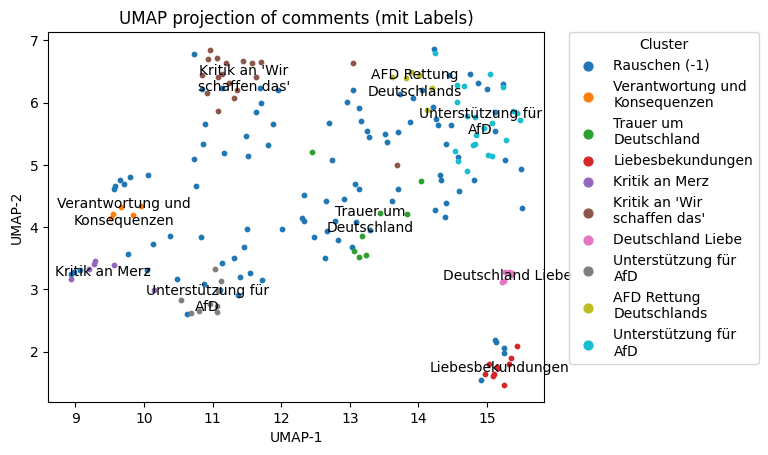

In [14]:

label_map = {}
for cid in sorted(set(df["cluster"].unique())):
    if cid == -1:
        label_map[cid] = "Rauschen (-1)"
    else:
        info = cluster_summaries.get(int(cid), {})
        lab = (info.get("label") or f"Cluster {cid}").strip()
        lab = fill(lab, width=18)  
        label_map[cid] = lab


df["cluster_name"] = df["cluster"].map(label_map)


plt.figure()
for cid in sorted(set(df["cluster"].unique())):
    sub = df[df["cluster"] == cid]
    plt.scatter(sub["x"], sub["y"], s=10, label=label_map[cid])

plt.legend(
    markerscale=2,
    title="Cluster",
    bbox_to_anchor=(1.05, 1),   
    loc="upper left",
    borderaxespad=0.
)

plt.title("UMAP projection of comments (mit Labels)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")


for cid in sorted(set(df["cluster"].unique())):
    if cid == -1:
        continue
    sub = df[df["cluster"] == cid]
    if len(sub) == 0:
        continue
    cx, cy = np.mean(sub["x"]), np.mean(sub["y"])
    plt.text(cx, cy, label_map[cid],
             ha="center", va="center")


os.makedirs("outputs", exist_ok=True)
labeled_plot_path = "outputs/umap_B_labeled.png"
plt.savefig(labeled_plot_path, dpi=200, bbox_inches="tight")
print("Saved:", labeled_plot_path)